<p style="font-size:24px; font-weight:bold;">Olist SQL Analysis</p>

Total Orders

C:\Users\England\AppData\Local\Temp\ipykernel_3764\3327422445.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


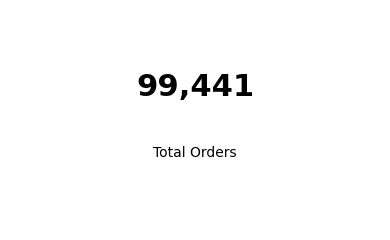

In [13]:
import matplotlib.pyplot as plt
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT COUNT(*) AS total_orders
FROM olist.orders;
"""

df = pd.read_sql(query, conn)
conn.close()

value = df.loc[0, 'total_orders']

plt.figure(figsize=(4, 2.5))
plt.axis('off')
plt.text(0.5, 0.65, f"{value:,}", ha='center', va='center', fontsize=22, weight='bold')
plt.text(0.5, 0.35, "Total Orders", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()


Total Revenue

C:\Users\England\AppData\Local\Temp\ipykernel_3764\3921109204.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


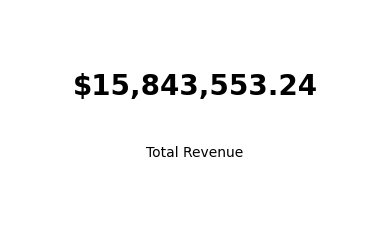

In [14]:
import matplotlib.pyplot as plt
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT SUM(oi.price + oi.freight_value) AS total_revenue
FROM olist.order_items oi;
"""

df = pd.read_sql(query, conn)
conn.close()

value = df.loc[0, 'total_revenue']

plt.figure(figsize=(4, 2.5))
plt.axis('off')
plt.text(0.5, 0.65, f"${value:,.2f}", ha='center', va='center', fontsize=20, weight='bold')
plt.text(0.5, 0.35, "Total Revenue", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()


Which top 10 sellers generated the highest revenue — and how many orders did each fulfill?


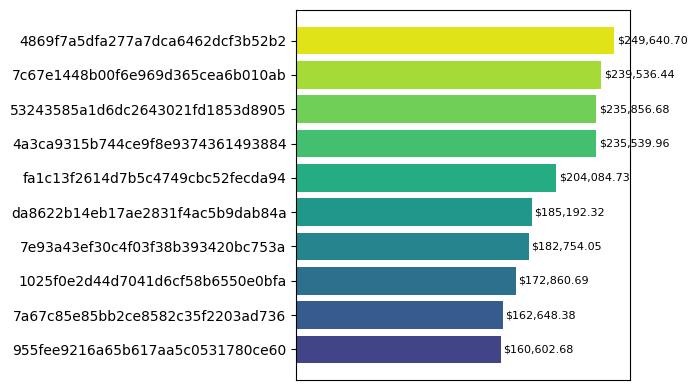

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df = df.sort_values('total_revenue', ascending=True)

cmap = plt.cm.viridis
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.barh(df['seller_id'], df['total_revenue'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + (width*0.01), bar.get_y() + bar.get_height()/2,
             f"${width:,.2f}", va='center', fontsize=8)

plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.grid(False)

plt.tight_layout()
plt.show()


What are the top 5 product categories by total revenue — and what is their average order value?

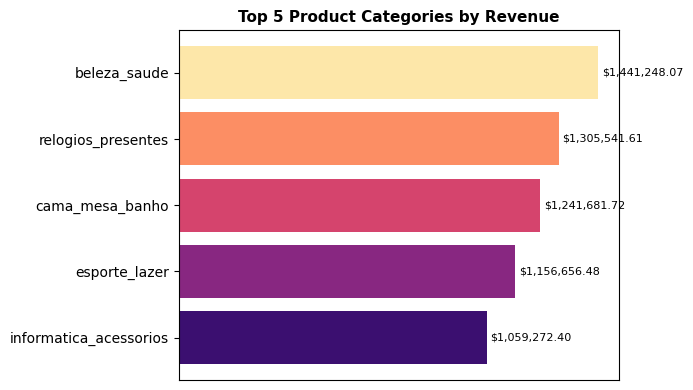

In [16]:
import matplotlib.pyplot as plt
import numpy as np

df = df.sort_values('total_revenue', ascending=True)

cmap = plt.cm.magma
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.barh(df['product_category_name'], df['total_revenue'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + (width*0.01), bar.get_y() + bar.get_height()/2,
             f"${width:,.2f}", va='center', fontsize=8)

plt.title("Top 5 Product Categories by Revenue", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.grid(False)

plt.tight_layout()
plt.show()


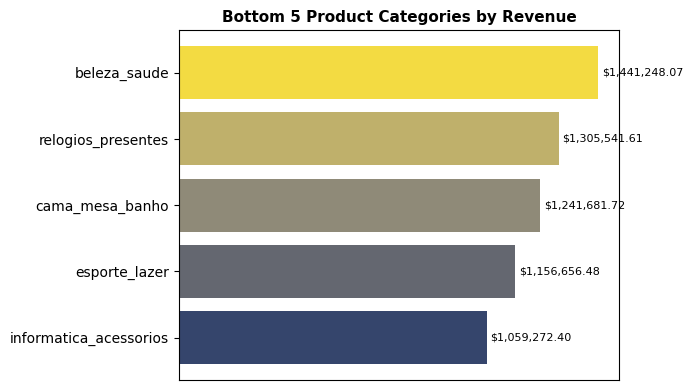

In [17]:
import matplotlib.pyplot as plt
import numpy as np

df = df.sort_values('total_revenue', ascending=True)

cmap = plt.cm.cividis
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.barh(df['product_category_name'], df['total_revenue'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + (width*0.01), bar.get_y() + bar.get_height()/2,
             f"${width:,.2f}", va='center', fontsize=8)

plt.title("Bottom 5 Product Categories by Revenue", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.grid(False)

plt.tight_layout()
plt.show()


Which month had the highest sales in 2017 vs 2018 — is the business growing year over year?


C:\Users\England\AppData\Local\Temp\ipykernel_3764\3012072217.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


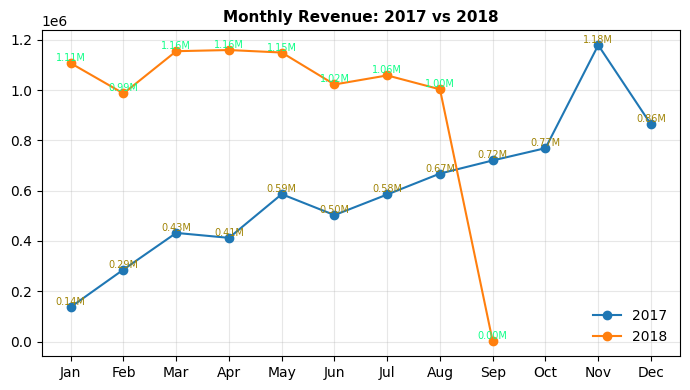

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
WITH monthly AS (
  SELECT
    EXTRACT(YEAR FROM o.order_purchase_timestamp) AS year,
    EXTRACT(MONTH FROM o.order_purchase_timestamp) AS month_num,
    TO_CHAR(o.order_purchase_timestamp, 'Mon') AS month_name,
    SUM(oi.price + oi.freight_value) AS total_revenue
  FROM olist.orders o
  JOIN olist.order_items oi ON o.order_id = oi.order_id
  WHERE EXTRACT(YEAR FROM o.order_purchase_timestamp) IN (2017, 2018)
  GROUP BY year, month_num, month_name
)
SELECT year, month_num, month_name, total_revenue
FROM monthly
ORDER BY year, month_num;
"""

df = pd.read_sql(query, conn)
conn.close()

pivot = df.pivot(index='month_num', columns='year', values='total_revenue').sort_index()

plt.figure(figsize=(7, 4))
plt.plot(pivot.index, pivot[2017], marker='o', color='#1f77b4', label='2017')
plt.plot(pivot.index, pivot[2018], marker='o', color='#ff7f0e', label='2018')

month_labels = df.drop_duplicates('month_num').sort_values('month_num')['month_name']
plt.xticks(pivot.index, month_labels)

for year, color in [(2017, "#a08406"), (2018, "#0eff87")]:
    for x, y in zip(pivot.index, pivot[year]):
        if pd.notna(y):
            plt.text(x, y, f"{y/1_000_000:.2f}M", fontsize=7, color=color,
                     ha='center', va='bottom')

plt.title("Monthly Revenue: 2017 vs 2018", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


What is the total revenue generated per state — which state is our biggest market?

C:\Users\England\AppData\Local\Temp\ipykernel_3764\3418804527.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


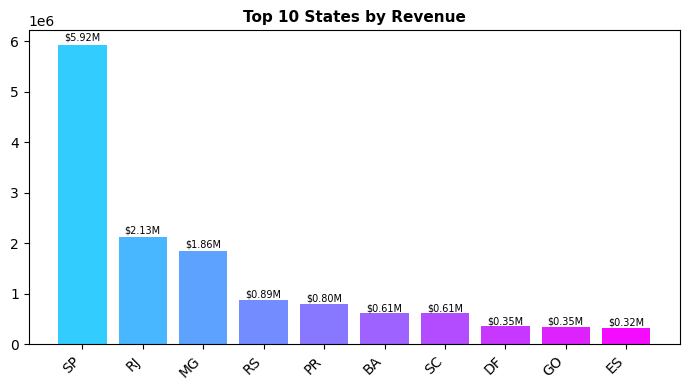

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  c.customer_state,
  SUM(oi.price + oi.freight_value) AS total_revenue
FROM olist.customers c
JOIN olist.orders o ON c.customer_id = o.customer_id
JOIN olist.order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY SUM(oi.price + oi.freight_value) DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)
conn.close()

cmap = plt.cm.cool
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.bar(df['customer_state'], df['total_revenue'], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (height*0.01),
             f"${height/1_000_000:.2f}M", ha='center', va='bottom', fontsize=7)

plt.title("Top 10 States by Revenue", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha='right')
plt.grid(False)

plt.tight_layout()
plt.show()


Which day of the week gets the most orders — are weekends busier than weekdays?


C:\Users\England\AppData\Local\Temp\ipykernel_3764\369590303.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


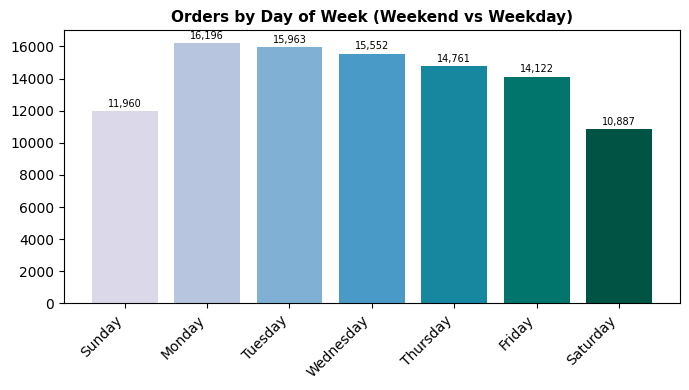

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  EXTRACT(DOW FROM order_purchase_timestamp) AS dow_num,
  TO_CHAR(order_purchase_timestamp, 'Day') AS day_name,
  COUNT(*) AS total_orders
FROM olist.orders
GROUP BY dow_num, day_name
ORDER BY dow_num;
"""

df = pd.read_sql(query, conn)
conn.close()

# Clean day names
df['day_name'] = df['day_name'].str.strip()

# Palette
cmap = plt.cm.PuBuGn
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.bar(df['day_name'], df['total_orders'], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (height*0.01),
             f"{int(height):,}", ha='center', va='bottom', fontsize=7)

plt.title("Orders by Day of Week (Weekend vs Weekday)", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha='right')
plt.grid(False)

plt.tight_layout()
plt.show()


What percentage of total orders were delivered late — and which seller had the worst late delivery rate?


C:\Users\England\AppData\Local\Temp\ipykernel_3764\1449142664.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


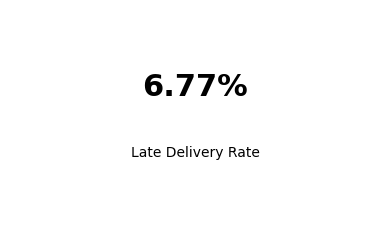

In [12]:
import matplotlib.pyplot as plt
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  ROUND(
    100.0 * SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END)
    / NULLIF(COUNT(*), 0), 2
  ) AS late_delivery_pct
FROM olist.orders
WHERE order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL;
"""

df = pd.read_sql(query, conn)
conn.close()

value = df.loc[0, 'late_delivery_pct']

plt.figure(figsize=(4, 2.5))
plt.axis('off')
plt.text(0.5, 0.65, f"{value:.2f}%", ha='center', va='center', fontsize=22, weight='bold')
plt.text(0.5, 0.35, "Late Delivery Rate", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()


What is the average delivery time in days by state — which state waits the longest?


C:\Users\England\AppData\Local\Temp\ipykernel_3764\2712257852.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


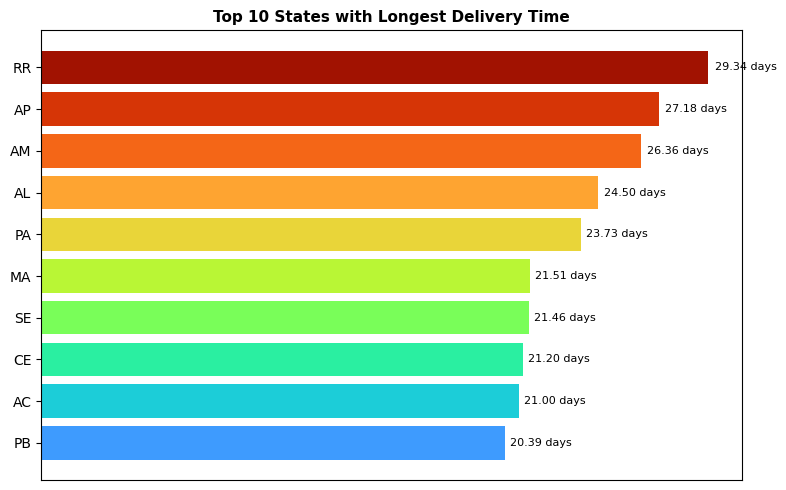

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  c.customer_state,
  ROUND(AVG(o.order_delivered_customer_date - o.order_purchase_timestamp), 2) AS avg_delivery_time_days
FROM olist.customers c
JOIN olist.orders o ON c.customer_id = o.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_time_days DESC;
"""

df = pd.read_sql(query, conn)
conn.close()

df_top = df.sort_values('avg_delivery_time_days', ascending=False).head(10)
df_top = df_top.sort_values('avg_delivery_time_days', ascending=True)

cmap = plt.cm.turbo
colors = cmap(np.linspace(0.2, 0.95, len(df_top)))

plt.figure(figsize=(8, 5))
bars = plt.barh(df_top['customer_state'], df_top['avg_delivery_time_days'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + (width*0.01), bar.get_y() + bar.get_height()/2,
             f"{width:.2f} days", va='center', fontsize=8)

plt.title("Top 10 States with Longest Delivery Time", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.grid(False)

plt.tight_layout()
plt.show()


Which product category takes the longest to deliver on average?

C:\Users\England\AppData\Local\Temp\ipykernel_3764\2096940435.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


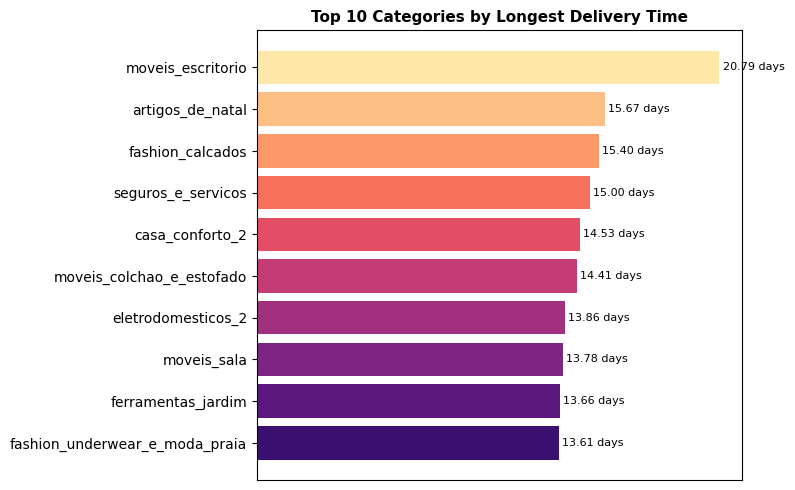

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  p.product_category_name,
  ROUND(AVG(o.order_delivered_customer_date - o.order_purchase_timestamp), 2) AS avg_delivery_days
FROM olist.order_items oi
JOIN olist.orders o ON oi.order_id = o.order_id
JOIN olist.products p ON oi.product_id = p.product_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY p.product_category_name
ORDER BY avg_delivery_days DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)
conn.close()

df = df.sort_values('avg_delivery_days', ascending=True)

cmap = plt.cm.magma
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(8, 5))
bars = plt.barh(df['product_category_name'], df['avg_delivery_days'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + (width*0.01), bar.get_y() + bar.get_height()/2,
             f"{width:.2f} days", va='center', fontsize=8)

plt.title("Top 10 Categories by Longest Delivery Time", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.grid(False)

plt.tight_layout()
plt.show()


Is delivery getting faster or slower over the months — show the trend?

C:\Users\England\AppData\Local\Temp\ipykernel_3764\2159095408.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


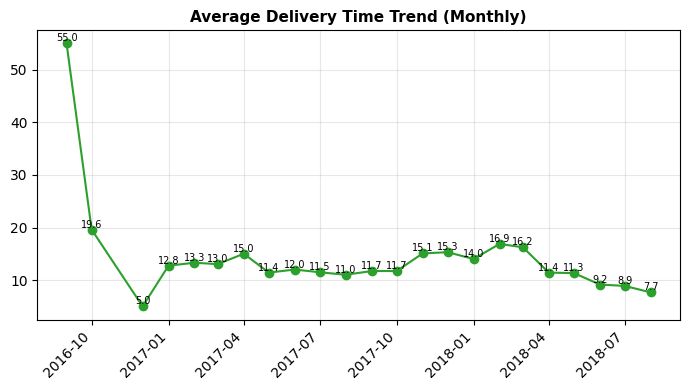

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
  ROUND(AVG(o.order_delivered_customer_date - o.order_purchase_timestamp), 2) AS avg_delivery_days
FROM olist.orders o
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY month
ORDER BY month;
"""

df = pd.read_sql(query, conn)
conn.close()

plt.figure(figsize=(7, 4))
plt.plot(df['month'], df['avg_delivery_days'], marker='o', color='#2ca02c')

for x, y in zip(df['month'], df['avg_delivery_days']):
    plt.text(x, y, f"{y:.1f}", fontsize=7, ha='center', va='bottom')

plt.title("Average Delivery Time Trend (Monthly)", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


How many sellers delivers before the estimated date more than 90% of the time?

C:\Users\England\AppData\Local\Temp\ipykernel_3764\3590218438.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


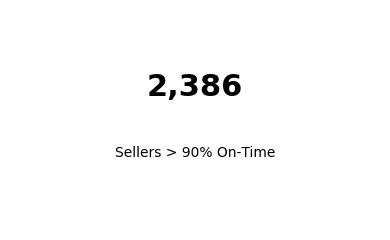

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
WITH seller_rates AS (
  SELECT
    oi.seller_id,
    AVG(CASE WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date THEN 1 ELSE 0 END) AS ontime_rate
  FROM olist.order_items oi
  JOIN olist.orders o ON oi.order_id = o.order_id
  WHERE o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
  GROUP BY oi.seller_id
)
SELECT COUNT(*) AS sellers_above_90
FROM seller_rates
WHERE ontime_rate > 0.90;
"""

df = pd.read_sql(query, conn)
conn.close()

value = df.loc[0, 'sellers_above_90']

plt.figure(figsize=(4, 2.5))
plt.axis('off')
plt.text(0.5, 0.65, f"{value:,}", ha='center', va='center', fontsize=22, weight='bold')
plt.text(0.5, 0.35, "Sellers > 90% On‑Time", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()


---Are review scores improving or declining month by month — show the full trend?

C:\Users\England\AppData\Local\Temp\ipykernel_3764\1304795689.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


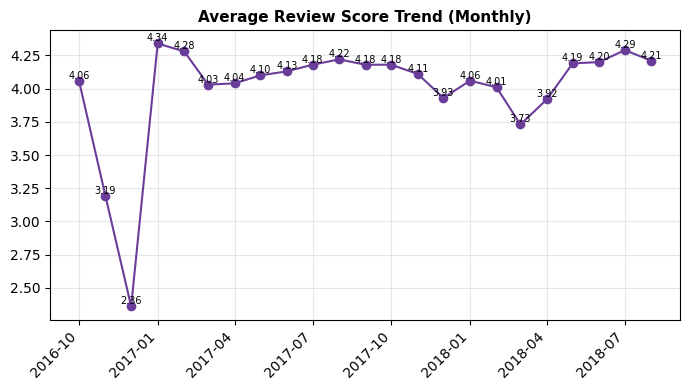

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  DATE_TRUNC('month', review_creation_date) AS month,
  ROUND(AVG(review_score), 2) AS avg_review_score
FROM olist.reviews
WHERE review_creation_date IS NOT NULL
GROUP BY month
ORDER BY month;
"""

df = pd.read_sql(query, conn)
conn.close()

plt.figure(figsize=(7, 4))
plt.plot(df['month'], df['avg_review_score'], marker='o', color='#6a3d9a')

for x, y in zip(df['month'], df['avg_review_score']):
    plt.text(x, y, f"{y:.2f}", fontsize=7, ha='center', va='bottom')

plt.title("Average Review Score Trend (Monthly)", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Lowest Reveiew Product

C:\Users\England\AppData\Local\Temp\ipykernel_3764\228215466.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


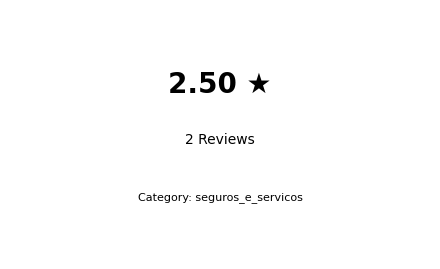

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  p.product_category_name,
  ROUND(AVG(r.review_score), 2) AS avg_review_score,
  COUNT(r.review_id) AS total_reviews
FROM olist.products p
JOIN olist.order_items oi ON p.product_id = oi.product_id
JOIN olist.reviews r ON oi.order_id = r.order_id
GROUP BY p.product_category_name
ORDER BY avg_review_score ASC
LIMIT 1;
"""

df = pd.read_sql(query, conn)
conn.close()

category = df.loc[0, 'product_category_name']
rating = df.loc[0, 'avg_review_score']
reviews = df.loc[0, 'total_reviews']

plt.figure(figsize=(4.5, 2.8))
plt.axis('off')
plt.text(0.5, 0.70, f"{rating:.2f} ★", ha='center', va='center', fontsize=20, weight='bold')
plt.text(0.5, 0.48, f"{reviews:,} Reviews", ha='center', va='center', fontsize=10)
plt.text(0.5, 0.25, f"Category: {category}", ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()


Unhappy States base on Reviews

C:\Users\England\AppData\Local\Temp\ipykernel_15840\4080415344.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


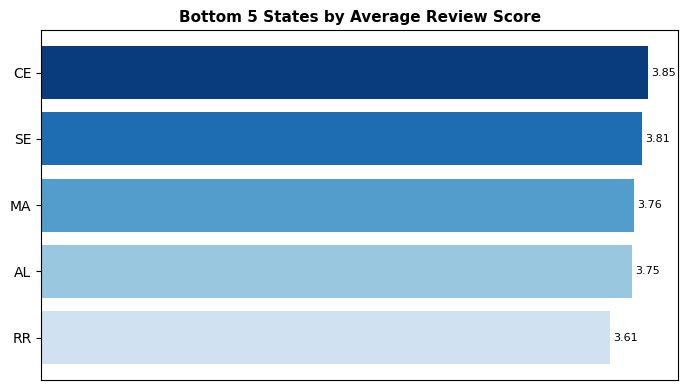

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  c.customer_state,
  ROUND(AVG(r.review_score), 2) AS avg_review_score,
  COUNT(r.review_id) AS total_reviews
FROM olist.customers c
JOIN olist.orders o ON c.customer_id = o.customer_id
JOIN olist.reviews r ON o.order_id = r.order_id
GROUP BY c.customer_state
ORDER BY avg_review_score ASC
LIMIT 5;
"""

df = pd.read_sql(query, conn)
conn.close()

df = df.sort_values('avg_review_score', ascending=True)

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.barh(df['customer_state'], df['avg_review_score'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center', fontsize=8)

plt.title("Bottom 5 States by Average Review Score", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks([])
plt.grid(False)

plt.tight_layout()
plt.show()


Our Repeat Customers

C:\Users\England\AppData\Local\Temp\ipykernel_15840\2295644563.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


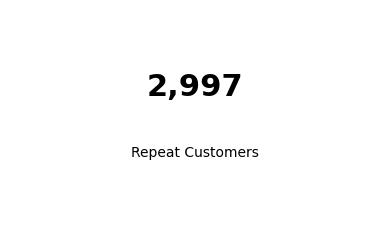

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
WITH customer_orders AS (
  SELECT
    customer_unique_id,
    COUNT(DISTINCT o.order_id) AS orders_count
  FROM olist.customers c
  JOIN olist.orders o ON c.customer_id = o.customer_id
  GROUP BY customer_unique_id
)
SELECT COUNT(*) AS repeat_customers
FROM customer_orders
WHERE orders_count > 1;
"""

df = pd.read_sql(query, conn)
conn.close()

value = df.loc[0, 'repeat_customers']

plt.figure(figsize=(4, 2.5))
plt.axis('off')
plt.text(0.5, 0.65, f"{value:,}", ha='center', va='center', fontsize=22, weight='bold')
plt.text(0.5, 0.35, "Repeat Customers", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()


The city with most Customers

C:\Users\England\AppData\Local\Temp\ipykernel_15840\2730838090.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


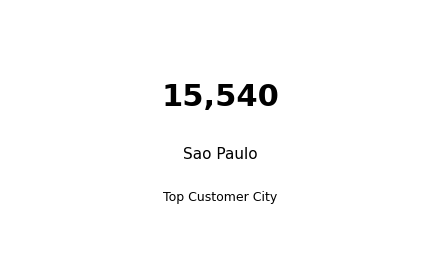

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  customer_city,
  COUNT(*) AS total_customers
FROM olist.customers
GROUP BY customer_city
ORDER BY total_customers DESC
LIMIT 1;
"""

df = pd.read_sql(query, conn)
conn.close()

city = df.loc[0, 'customer_city']
count = df.loc[0, 'total_customers']

plt.figure(figsize=(4.5, 2.8))
plt.axis('off')
plt.text(0.5, 0.65, f"{count:,}", ha='center', va='center', fontsize=22, weight='bold')
plt.text(0.5, 0.42, f"{city.title()}", ha='center', va='center', fontsize=11)
plt.text(0.5, 0.25, "Top Customer City", ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()


Average Order Value

C:\Users\England\AppData\Local\Temp\ipykernel_15840\4026100401.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


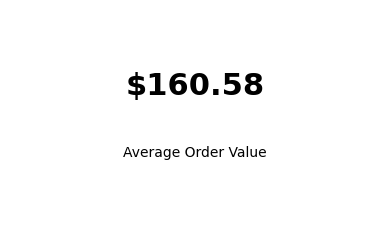

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT ROUND(AVG(order_total)::numeric, 2) AS avg_order_value
FROM (
  SELECT order_id, SUM(price + freight_value) AS order_total
  FROM olist.order_items
  GROUP BY order_id
) t;
"""


df = pd.read_sql(query, conn)
conn.close()

value = df.loc[0, 'avg_order_value']

plt.figure(figsize=(4, 2.5))
plt.axis('off')
plt.text(0.5, 0.65, f"${value:,.2f}", ha='center', va='center', fontsize=22, weight='bold')
plt.text(0.5, 0.35, "Average Order Value", ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()


Most Favourite Method of Payment

C:\Users\England\AppData\Local\Temp\ipykernel_15840\1829593920.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


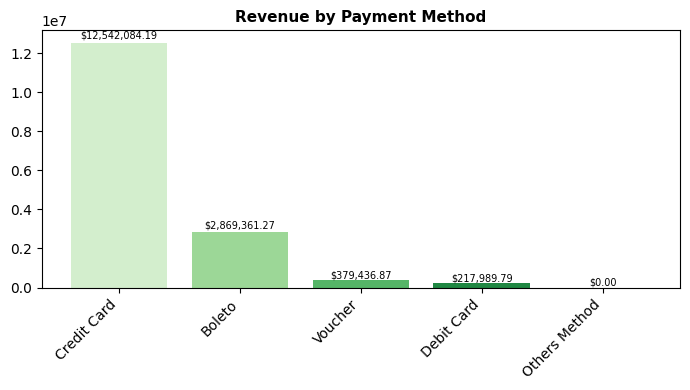

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    user="postgres",
    password="England1920",
    dbname="olist_db"
)

query = """
SELECT
  payment_type,
  SUM(payment_value) AS total_revenue
FROM olist.payments
GROUP BY payment_type
ORDER BY total_revenue DESC;
"""

df = pd.read_sql(query, conn)
conn.close()

cmap = plt.cm.Greens
colors = cmap(np.linspace(0.2, 0.95, len(df)))

plt.figure(figsize=(7, 4))
bars = plt.bar(df['payment_type'], df['total_revenue'], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (height*0.01),
             f"${height:,.2f}", ha='center', va='bottom', fontsize=7)

plt.title("Revenue by Payment Method", fontsize=11, weight='bold')
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha='right')
plt.grid(False)

plt.tight_layout()
plt.show()
